### Modelo CNN capaz de classficar filtros gaussianos com diferentes larguras

In [1]:
# importações
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# infos sobre modelos
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

### Criando os Gaussian Blurs com larguras diferentes

In [23]:
nPerClass = 1000
imgSize = 91

x = np.linspace(-4,4,imgSize)
X,Y = np.meshgrid(x,x)

# larguras (sigma)
widths = [1.8,2.4]

# Inicializando os tensores com imagens e rótulos
images = torch.zeros(2*nPerClass, 1, imgSize, imgSize)
labels = torch.zeros(2*nPerClass)

for i in range(2*nPerClass):

    # Criando os gaussianos com centros aleatórios
    ro = 2*np.random.randn(2) # r0 = random offset
    G = np.exp( -( (X-ro[0])**2 + (Y-ro[1])**2) / (2*widths[i%2]**2) )

    # adicionando um pouco de ruído
    G = G + np.random.randn(imgSize, imgSize)/5

    # adicionando ao tensor
    images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize)
    labels[i] = i%2

labels = labels[:,None] # reshape para coluna

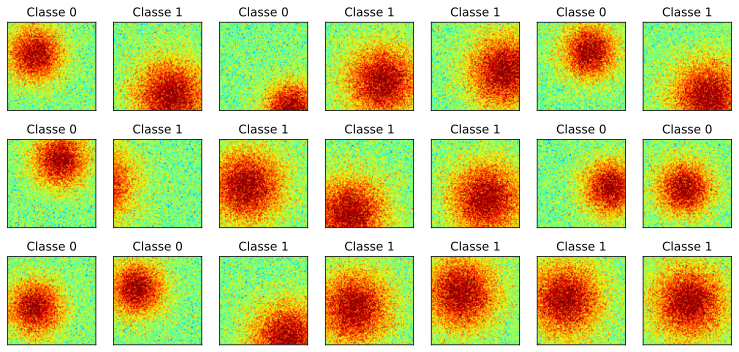

In [24]:
# Visualizando algumas imagens
fig,axs = plt.subplots(3,7,figsize=(13,6))

for i,ax, in enumerate(axs.flatten()):
    whichpic = np.random.randint(2*nPerClass)
    G = np.squeeze(images[whichpic,:,:])
    ax.imshow(G, vmin=-1, vmax=1, cmap='jet')
    ax.set_title('Classe %s'%int(labels[whichpic].item()))
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

### Criando divisão de treino/teste usando o DataLoader

In [25]:
# dividindo em treino e teste
train_data, test_data, train_labels, test_labels = train_test_split(images, labels, test_size=.1)

# Convertendo em DataSets do PyTorch
train_data = TensorDataset(train_data, train_labels)
test_data = TensorDataset(test_data, test_labels)

# Criando os DataLoaders
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [26]:
# cheacando o tamahho (imagens, canais, largura, altura)
print(train_loader.dataset.tensors[0].shape)
print(train_loader.dataset.tensors[1].shape)

torch.Size([1800, 1, 91, 91])
torch.Size([1800, 1])


### Arquitetura do modelo

In [27]:
'''
Existem diversas maneiras de criar a arquitetura do modelo, essa é visualmente mais organizada, 
mas existem outras formas de criar a arquitetura, como por exemplo criando cada camada separadamente 
e depois usando elas no forward. O importante é entender o que cada camada faz e como elas se conectam.
'''
# Criando classe do modelo, podemos combinar a criação de classes personalizas com nn.Sequential para criar as camadas de forma fácil
def createTheNet():

    class gaussnet(nn.Module):
        def __init__(self):
            super().__init__()

            # Criando todas as camadas de forma fácil usando nn.Sequential
            self.enc = nn.Sequential(
                nn.Conv2d(1,6,3,padding=1), # output: (91+2*1-3)/1 + 1 = 91, canais = 6
                nn.ReLU(), # ReLU é tratada como uma "camada"
                nn.AvgPool2d(2,2), # output: (91-2)/2 + 1 = 45, canais = 6
                nn.Conv2d(6,4,3,padding=1), # output: (45+2*1-3)/1 + 1 = 45, canais = 4
                nn.ReLU(),
                nn.AvgPool2d(2,2), # output: (45-2)/2 + 1 = 22, canais = 4
                nn.Flatten(), # output: 22*22*4 = 1936
                nn.Linear(22*22*4, 50), # output: 50
                nn.Linear(50, 1) # output: 1
            )

        def forward(self,x):
            return self.enc(x)
        
    # Criando a rede
    net = gaussnet()

    # loss function
    lossfun = nn.BCEWithLogitsLoss()

    # otimizador
    optimizer = torch.optim.Adam(net.parameters(), lr=.001)

    return net, lossfun, optimizer

In [28]:
# Testando o modelo com um batch
net, lossfun, optimizer = createTheNet()

X,y = next(iter(train_loader))
yHat = net(X)

# Checando o tamanho da saída
print(' ')
print(yHat.shape)

# Computando a loss
loss = lossfun(yHat, y)
print(' ')
print('Loss:')
print(loss)

 
torch.Size([32, 1])
 
Loss:
tensor(0.7048, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [29]:
# Número de parâmetros que podem ser aprendidos por backpropagation no modelo
summary(net, input_size=(1, imgSize, imgSize))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         AvgPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         AvgPool2d-6            [-1, 4, 22, 22]               0
           Flatten-7                 [-1, 1936]               0
            Linear-8                   [-1, 50]          96,850
            Linear-9                    [-1, 1]              51
Total params: 97,181
Trainable params: 97,181
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.00
Params size (MB): 0.37
Estimated Total Size (MB): 1.41
---------------------------------------------

### Função de treinamento do modelo

In [30]:
# função que treina o modelo

def function2trainTheModel():

  # number of epochs
  numepochs = 10
  
  # creiando um novo modelo
  net,lossfun,optimizer = createTheNet()

  # inicializando perdas
  trainLoss = torch.zeros(numepochs)
  testLoss  = torch.zeros(numepochs)
  trainAcc  = torch.zeros(numepochs)
  testAcc   = torch.zeros(numepochs)


  # loop sobre as épocas
  for epochi in range(numepochs):

    # loop sobree os batches de treino
    batchLoss = []
    batchAcc  = []
    for X,y in train_loader:

      # forward pass e loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # perda deste batch
      batchLoss.append(loss.item())
      batchAcc.append( torch.mean(( (yHat>0) ==y).float()).item() )
    # fim do loop de batches...

    # pegando as perdas médias dos batches
    trainLoss[epochi] = np.mean(batchLoss)
    trainAcc[epochi]  = 100*np.mean(batchAcc)

    # acurácia de teste
    X,y = next(iter(test_loader)) # extraindo X,y do test dataloader
    with torch.no_grad(): # desativa autograd
      yHat = net(X)
      loss = lossfun(yHat,y)
      
    # comparando a seguinte linha de código com as linhas de acurácia de treino
    testLoss[epochi] = loss.item()
    testAcc[epochi]  = 100*torch.mean(( (yHat>0) ==y).float()).item()

  # fim das epocas

  # output
  return trainLoss,testLoss,trainAcc,testAcc,net

### Rodando o modelo

In [31]:
trainLoss,testLoss,trainAcc,testAcc,net = function2trainTheModel()

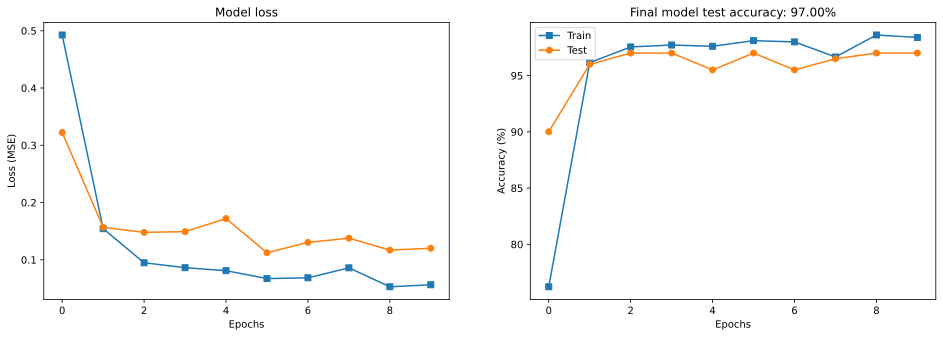

In [32]:
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(trainLoss,'s-',label='Train')
ax[0].plot(testLoss,'o-',label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,'s-',label='Train')
ax[1].plot(testAcc,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()

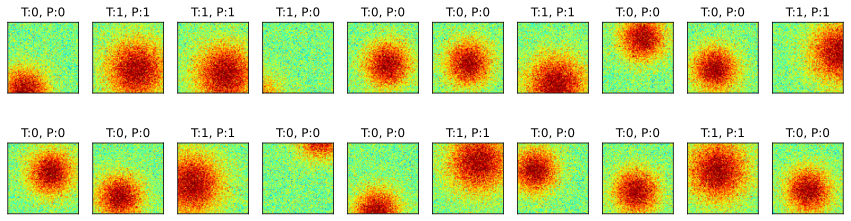

In [ ]:
# visualizando algumas imagens de teste com suas predições

X,y = next(iter(test_loader)) # extraindo X,y do test dataloader
yHat = net(X)

fig,axs = plt.subplots(2,10,figsize=(15,4))

for i,ax in enumerate(axs.flatten()):
  G = torch.squeeze( X[i,0,:,:] ).detach()
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet')
  t = ( int(y[i].item()) , int(yHat[i].item()>0) )
  ax.set_title('T:%s, P:%s'%t)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

In [34]:
# Olhando nossos filtros
print(net)

layer1W = net.enc[0].weight
layer3W = net.enc[3].weight

print(' ')
print(layer1W.shape)
print(layer3W.shape)

gaussnet(
  (enc): Sequential(
    (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1936, out_features=50, bias=True)
    (8): Linear(in_features=50, out_features=1, bias=True)
  )
)
 
torch.Size([6, 1, 3, 3])
torch.Size([4, 6, 3, 3])


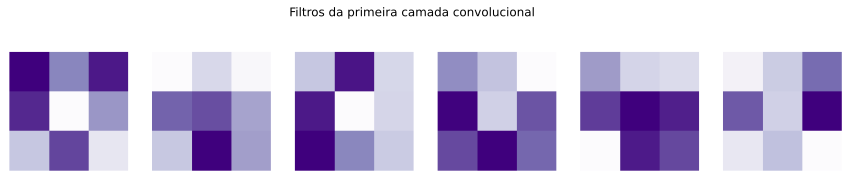

In [36]:
fig,axs = plt.subplots(1,6,figsize=(15,3))

for i,ax in enumerate(axs.flatten()):
  ax.imshow( torch.squeeze(layer1W[i,:,:,:]).detach() ,cmap='Purples')
  ax.axis('off')

plt.suptitle('Filtros da primeira camada convolucional')
plt.show()

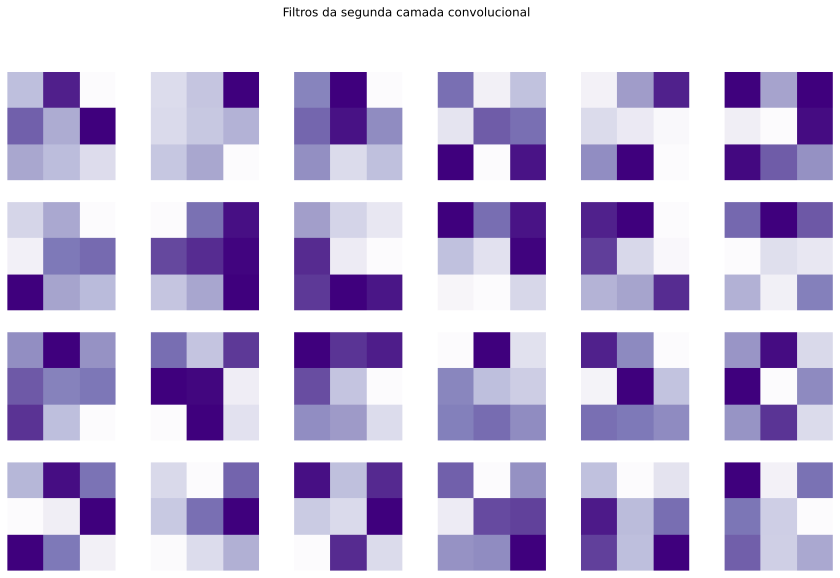

In [ ]:
'''
Lembre-se que a segunda camada convolucional tem 4 filtros, cada um conectado a todos os 6 canais de saída da primeira camada,
então cada filtro da segunda camada tem 6 "fatias" (uma para cada canal de saída da primeira camada), e cada fatia tem 3x3 pesos. 
Então para visualizar os filtros da segunda camada, precisamos visualizar cada fatia de cada filtro, o que resulta em 4x6 imagens (4 filtros, cada um com 6 fatias).
'''

fig,axs = plt.subplots(4,6,figsize=(15,9))

for i in range(6*4):
  idx = np.unravel_index(i,(4,6))
  axs[idx].imshow( torch.squeeze(layer3W[idx[0],idx[1],:,:]).detach() ,cmap='Purples')
  axs[idx].axis('off')

plt.suptitle('Filtros da segunda camada convolucional')
plt.show()